# Experiment C — Transformer + Improved Feature Analysis

Combines both improvements: **DistilBERT** as the model with **char n-gram analysis**
applied to understand what the transformer attends to versus what char n-grams capture.

Two components run in this notebook:

1. **DistilBERT fine-tuning** on full Sentiment140 (same as Experiment B)
2. **Attention + char n-gram analysis** — visualises which tokens the transformer
   attends to, and compares against the most discriminative char n-grams from
   Experiment A to understand what each representation captures

Install dependencies if needed:
```
pip install transformers datasets torch accelerate bertviz
```

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import torch

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)
from scipy.sparse import hstack

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset

import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

/Users/owenblanchard/Documents/AIT-Budapest/Deep Learning/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


## 2. Load & Clean Dataset

In [2]:
DATASET_PATH = 'training.1600000.processed.noemoticon.csv'

df = pd.read_csv(
    DATASET_PATH,
    encoding='latin-1',
    header=None,
    names=['target', 'id', 'date', 'flag', 'user', 'text']
)

df['label_str'] = df['target'].map({0: 'negative', 4: 'positive'})
df['label']     = df['target'].map({0: 0,          4: 1})          # int labels for Trainer

def clean_tweet(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+',    '',      text)
    text = re.sub(r'@\w+',              '',      text)
    text = re.sub(r'#(\w+)',            r'\1',   text)
    text = re.sub(r"n't\b",            ' not',  text)
    text = re.sub(r'(.)\1{2,}',         r'\1\1', text)
    text = re.sub(r'[^\x00-\x7F]+',     '',      text)
    text = re.sub(r'\s+',               ' ',     text).strip().lower()
    return text

df['text_clean'] = df['text'].apply(clean_tweet)
df = df[df['text_clean'].str.len() > 0].reset_index(drop=True)
print(f'Loaded {len(df):,} samples')

Loaded 1,597,119 samples


## 3. Subsample

`USE_FULL_DATASET = True` by default — full 1.6M for best transformer performance.
Char n-gram analysis in section 9 uses a fixed 200k subsample regardless of this flag.

In [3]:
USE_FULL_DATASET = True
SAMPLE_PER_CLASS = 200_000

if not USE_FULL_DATASET:
    neg = df[df['label'] == 0].sample(n=SAMPLE_PER_CLASS, random_state=42)
    pos = df[df['label'] == 1].sample(n=SAMPLE_PER_CLASS, random_state=42)
    df_work = pd.concat([neg, pos]).sample(frac=1, random_state=42).reset_index(drop=True)
else:
    df_work = df.copy()

print(f'Working with {len(df_work):,} samples')
print(df_work['label'].value_counts())

Working with 1,597,119 samples
label
1    798642
0    798477
Name: count, dtype: int64


## 4. Train / Dev / Test Split

In [4]:
X     = df_work['text_clean'].tolist()
y_int = df_work['label'].tolist()
y_str = df_work['label_str'].tolist()

X_traindev, X_test, y_traindev, y_test = train_test_split(
    X, y_int, test_size=0.2, random_state=42, stratify=y_int
)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_traindev, y_traindev, test_size=0.125, random_state=42, stratify=y_traindev
)

# String label versions for the char n-gram model (sections 9–10)
X_tr_str, X_te_str, y_tr_str, y_te_str = train_test_split(
    X, y_str, test_size=0.2, random_state=42, stratify=y_str
)

print(f'Train: {len(X_train):,}  |  Dev: {len(X_dev):,}  |  Test: {len(X_test):,}')

Train: 1,117,983  |  Dev: 159,712  |  Test: 319,424


## 5. Tokenise for DistilBERT

In [5]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 128

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenise_batch(texts, labels):
    enc = tokenizer(
        texts,
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH,
        return_tensors=None
    )
    enc['labels'] = labels
    return enc

print('Tokenising splits...')
train_ds = Dataset.from_dict(tokenise_batch(X_train, y_train))
dev_ds   = Dataset.from_dict(tokenise_batch(X_dev,   y_dev))
test_ds  = Dataset.from_dict(tokenise_batch(X_test,  y_test))

train_ds.set_format('torch')
dev_ds.set_format('torch')
test_ds.set_format('torch')
print('Tokenisation complete.')

Tokenising splits...
Tokenisation complete.


## 6. Load Model & Configure Training

In [6]:
id2label = {0: 'negative', 1: 'positive'}
label2id = {'negative': 0, 'positive': 1}

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, id2label=id2label, label2id=label2id
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro')
    }

training_args = TrainingArguments(
    output_dir                  = './distilbert_expC',
    num_train_epochs             = 3,
    per_device_train_batch_size  = 64,
    per_device_eval_batch_size   = 128,
    learning_rate                = 2e-5,
    warmup_ratio                 = 0.1,
    weight_decay                 = 0.01,
    eval_strategy                = 'epoch',
    save_strategy                = 'epoch',
    load_best_model_at_end       = True,
    metric_for_best_model        = 'f1_macro',
    fp16                         = (device == 'cuda'),
    logging_steps                = 500,
    report_to                    = 'none',
    dataloader_num_workers       = 4
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = dev_ds,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
)

print('Trainer configured.')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8666.99it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer configured.


## 7. Train DistilBERT

In [7]:
train_result =  trainer.train(resume_from_checkpoint='./distilbert_sentiment140/checkpoint-52407')
print(f'Training complete. Loss: {train_result.training_loss:.4f}')

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Epoch,Training Loss,Validation Loss


Training complete. Loss: 0.0000


## 8. Evaluate DistilBERT on Test Set

Test Accuracy: 0.8677

              precision    recall  f1-score   support

    negative       0.86      0.87      0.87    159695
    positive       0.87      0.86      0.87    159729

    accuracy                           0.87    319424
   macro avg       0.87      0.87      0.87    319424
weighted avg       0.87      0.87      0.87    319424



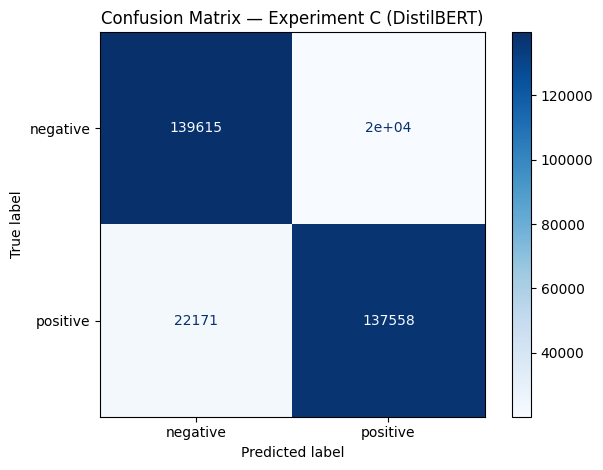

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.32it/s]

Model saved to ./distilbert_expC_final


In [8]:
test_output    = trainer.predict(test_ds)
y_test_pred    = np.argmax(test_output.predictions, axis=1)
y_test_true    = test_output.label_ids

print(f'Test Accuracy: {accuracy_score(y_test_true, y_test_pred):.4f}\n')
print(classification_report(y_test_true, y_test_pred, target_names=['negative', 'positive']))

cm = confusion_matrix(y_test_true, y_test_pred)
ConfusionMatrixDisplay(cm, display_labels=['negative', 'positive']).plot(cmap='Blues')
plt.title('Confusion Matrix — Experiment C (DistilBERT)')
plt.tight_layout()
plt.show()

# Save model for reuse
trainer.save_model('./distilbert_expC_final')
tokenizer.save_pretrained('./distilbert_expC_final')
print('Model saved to ./distilbert_expC_final')

## 9. Char N-gram Analysis (ComplementNB)

Trains the char n-gram NaiveBayes model from Experiment A on the same data split.
Used purely for feature analysis — to understand what character-level patterns
carry sentiment signal, and whether the transformer implicitly learns the same patterns.

In [9]:
# Use a 200k subsample for char n-gram analysis regardless of USE_FULL_DATASET
CHAR_SAMPLE = 100_000
neg_c = df[df['label_str'] == 'negative'].sample(n=CHAR_SAMPLE, random_state=42)
pos_c = df[df['label_str'] == 'positive'].sample(n=CHAR_SAMPLE, random_state=42)
df_char = pd.concat([neg_c, pos_c]).sample(frac=1, random_state=42).reset_index(drop=True)

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    df_char['text_clean'], df_char['label_str'],
    test_size=0.2, random_state=42, stratify=df_char['label_str']
)

vec_word = TfidfVectorizer(
    analyzer='word', stop_words='english', ngram_range=(1, 3),
    min_df=2, sublinear_tf=True, max_features=150_000
)
vec_char = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(3, 5),
    min_df=3, sublinear_tf=True, max_features=100_000
)

Xctr = hstack([vec_word.fit_transform(Xc_tr), vec_char.fit_transform(Xc_tr)])
Xcte = hstack([vec_word.transform(Xc_te),     vec_char.transform(Xc_te)])

nb_model = ComplementNB(alpha=0.05)
nb_model.fit(Xctr, yc_tr)

yc_pred = nb_model.predict(Xcte)
print(f'Char NB Test Accuracy: {accuracy_score(yc_te, yc_pred):.4f}\n')
print(classification_report(yc_te, yc_pred, target_names=['negative', 'positive']))

Char NB Test Accuracy: 0.7658

              precision    recall  f1-score   support

    negative       0.76      0.77      0.77     20000
    positive       0.77      0.76      0.76     20000

    accuracy                           0.77     40000
   macro avg       0.77      0.77      0.77     40000
weighted avg       0.77      0.77      0.77     40000



## 10. Feature Comparison — Char N-grams vs Attention

Side-by-side: top char n-gram features from the NaiveBayes model (left) vs
attention weights from DistilBERT on the same example tweets (right).

This reveals which representations each model relies on:
- NaiveBayes char n-grams are explicit and inspectable
- DistilBERT attention reflects contextual token importance across all heads

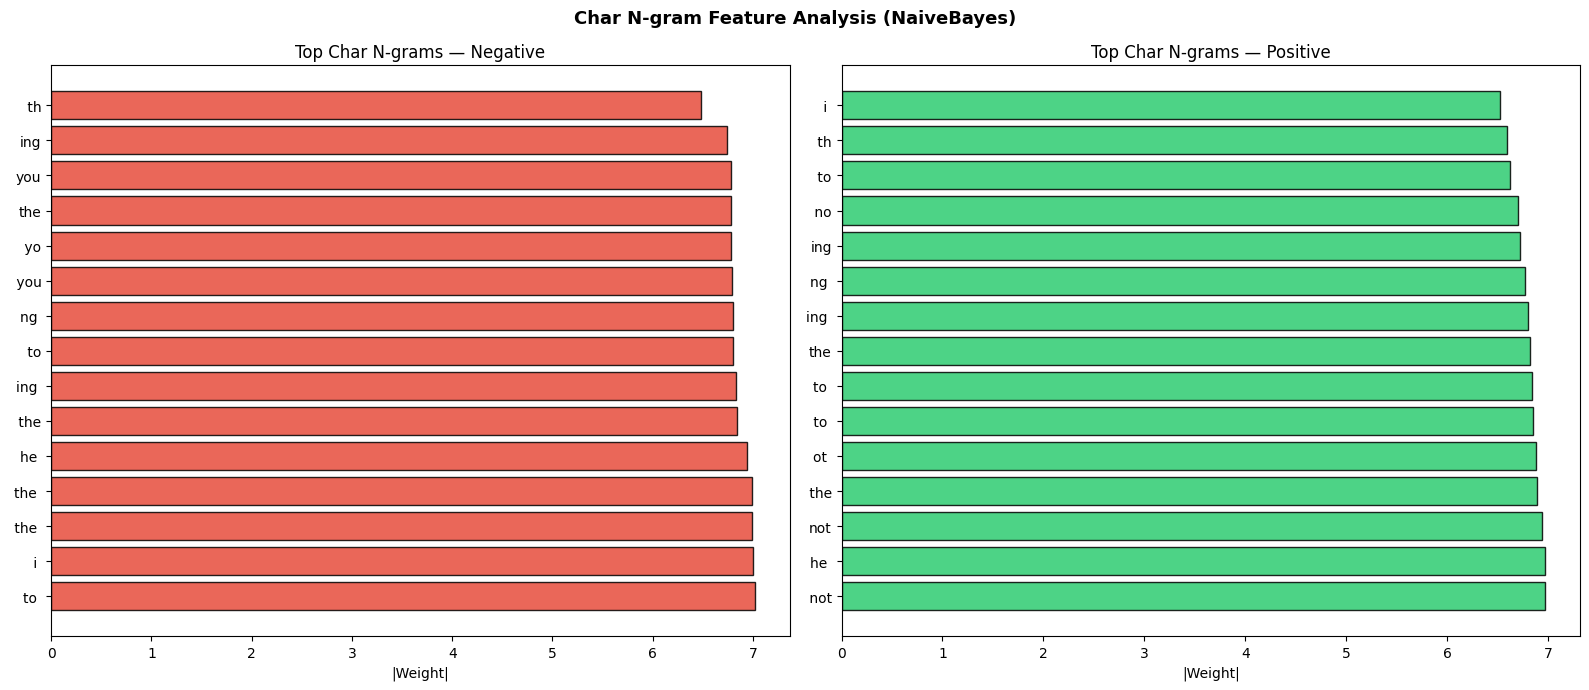

In [10]:
# ── Char n-gram top features ──────────────────────────────────────────────
word_vocab_size = len(vec_word.vocabulary_)
all_features    = np.array(
    vec_word.get_feature_names_out().tolist() +
    vec_char.get_feature_names_out().tolist()
)

def get_top_char(model, all_features, word_vocab_size, class_label, n=15):
    class_idx = list(model.classes_).index(class_label)
    weights   = model.feature_log_prob_[class_idx]
    top_idx   = np.argsort(weights)[:n * 3]
    return [(all_features[i], weights[i]) for i in top_idx if i >= word_vocab_size][:n]

colors = {'negative': '#e74c3c', 'positive': '#2ecc71'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, cls in zip(axes, ['negative', 'positive']):
    feats = get_top_char(nb_model, all_features, word_vocab_size, cls, n=15)
    if feats:
        words, scores = zip(*feats)
        ax.barh(words[::-1], np.abs(scores[::-1]), color=colors[cls], edgecolor='black', alpha=0.85)
    ax.set_title(f'Top Char N-grams — {cls.capitalize()}')
    ax.set_xlabel('|Weight|')

plt.suptitle('Char N-gram Feature Analysis (NaiveBayes)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 13113.50it/s]


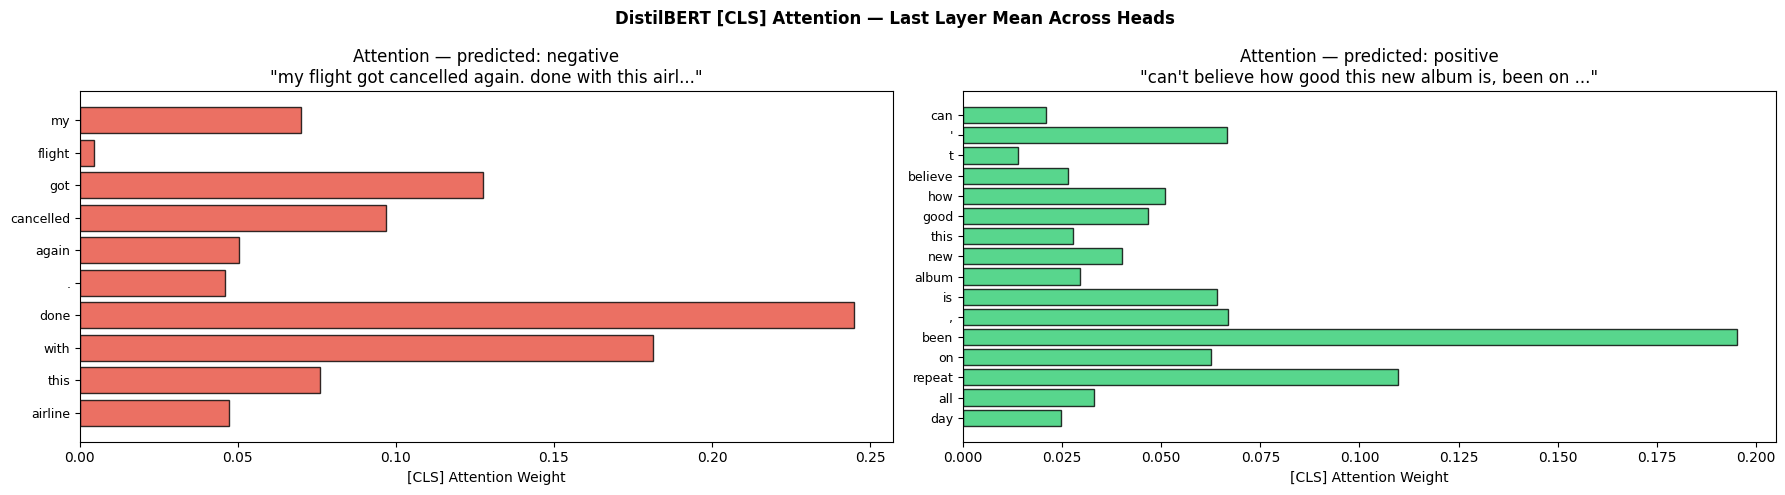

In [11]:
# ── DistilBERT attention on example tweets ────────────────────────────────
# Reload model with output_attentions=True
attn_model = DistilBertForSequenceClassification.from_pretrained(
    './distilbert_expC_final',
    output_attentions=True
).to(device)
attn_model.eval()

probe_tweets = [
    "my flight got cancelled again. done with this airline",   # negative
    "can't believe how good this new album is, been on repeat all day"  # positive
]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, tweet in zip(axes, probe_tweets):
    enc    = tokenizer(tweet, return_tensors='pt', truncation=True, max_length=MAX_LENGTH).to(device)
    tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'][0])

    with torch.no_grad():
        out = attn_model(**enc)

    # Average attention across all heads in the last layer
    last_layer_attn = out.attentions[-1][0]         # (n_heads, seq_len, seq_len)
    mean_attn       = last_layer_attn.mean(dim=0)   # (seq_len, seq_len)
    cls_attn        = mean_attn[0, 1:-1].cpu().numpy()  # [CLS] attending to content tokens
    content_tokens  = tokens[1:len(cls_attn)+1]

    pred_label = id2label[out.logits.argmax().item()]

    ax.barh(range(len(content_tokens)), cls_attn[::-1],
            color=colors.get(pred_label, 'steelblue'), edgecolor='black', alpha=0.8)
    ax.set_yticks(range(len(content_tokens)))
    ax.set_yticklabels(content_tokens[::-1], fontsize=9)
    ax.set_xlabel('[CLS] Attention Weight')
    ax.set_title(f'Attention — predicted: {pred_label}\n"{tweet[:50]}..."')

plt.suptitle('DistilBERT [CLS] Attention — Last Layer Mean Across Heads',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Cross-Experiment Comparison

=== CROSS-EXPERIMENT COMPARISON ===
                    Experiment Test Accuracy Test F1 (macro) F1 (negative) F1 (positive)
         Baseline (NaiveBayes)        0.7467          0.7466        0.7475        0.7458
         A — Improved Features        0.7726          0.7725        0.7763        0.7687
                B — DistilBERT        0.8677          0.8677        0.8686        0.8668
C — DistilBERT + Char Analysis        0.8677          0.8677        0.8686        0.8669

Saved to experiment_c_comparison.csv


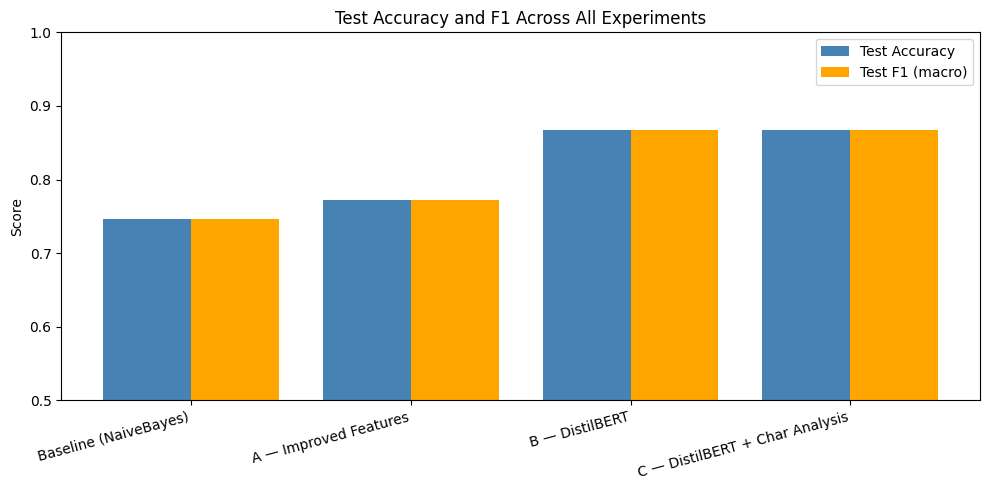

In [12]:
# Load results from previous experiments if available
import os

records = []
for fname, exp in [
    ('baseline_results.csv',      'Baseline (NaiveBayes)'),
    ('experiment_a_results.csv',  'A — Improved Features'),
    ('experiment_b_results.csv',  'B — DistilBERT'),
]:
    if os.path.exists(fname):
        r = pd.read_csv(fname).set_index('Metric')['Value'].to_dict()
        records.append({
            'Experiment':      exp,
            'Test Accuracy':   r.get('Test accuracy', '-'),
            'Test F1 (macro)': r.get('Test F1 (macro)', '-'),
            'F1 (negative)':   r.get('Test F1 (negative)', '-'),
            'F1 (positive)':   r.get('Test F1 (positive)', '-'),
        })

# Add current experiment C results
records.append({
    'Experiment':      'C — DistilBERT + Char Analysis',
    'Test Accuracy':   round(accuracy_score(y_test_true, y_test_pred), 4),
    'Test F1 (macro)': round(f1_score(y_test_true, y_test_pred, average='macro'), 4),
    'F1 (negative)':   round(f1_score(y_test_true, y_test_pred, pos_label=0, average='binary'), 4),
    'F1 (positive)':   round(f1_score(y_test_true, y_test_pred, pos_label=1, average='binary'), 4),
})

comparison_df = pd.DataFrame(records)
print('=== CROSS-EXPERIMENT COMPARISON ===')
print(comparison_df.to_string(index=False))
comparison_df.to_csv('experiment_c_comparison.csv', index=False)
print('\nSaved to experiment_c_comparison.csv')

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(comparison_df))
acc_vals = [float(v) for v in comparison_df['Test Accuracy']]
f1_vals  = [float(v) for v in comparison_df['Test F1 (macro)']]
ax.bar([i - 0.2 for i in x], acc_vals, width=0.4, label='Test Accuracy', color='steelblue')
ax.bar([i + 0.2 for i in x], f1_vals,  width=0.4, label='Test F1 (macro)', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Experiment'], rotation=15, ha='right')
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Test Accuracy and F1 Across All Experiments')
ax.legend()
plt.tight_layout()
plt.show()